In [2]:
"""
LSQ vs SVR对比实验 - 网络负载300M offset回归效果比较
基于load_analysis.py的逻辑，对比分段最小二乘回归(LSQ)与支持向量回归(SVR)的效果
"""
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVR
import warnings
import time
warnings.filterwarnings('ignore')

# 设置matplotlib中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 设置图形显示参数 - 提高分辨率
plt.rcParams['figure.dpi'] = 150  # 提高显示分辨率
plt.rcParams['savefig.dpi'] = 300  # 提高保存分辨率
plt.rcParams['font.size'] = 12  # 增加默认字体大小
plt.rcParams['axes.labelsize'] = 14  # 坐标轴标签字体大小
plt.rcParams['axes.titlesize'] = 16  # 标题字体大小
plt.rcParams['legend.fontsize'] = 12  # 图例字体大小
plt.rcParams['xtick.labelsize'] = 11  # x轴刻度标签字体大小
plt.rcParams['ytick.labelsize'] = 11  # y轴刻度标签字体大小

In [3]:
def load_network_300m_data():
    """加载网络负载300M的测试数据"""
    print("\n 加载网络负载300M数据...")
    
    # 数据文件路径
    data_file = r"c:\Git_Code\Clock_Sync\data\load_tests_0612\traffic_load\流量负载\log0-original_300M.log"
    
    if not os.path.exists(data_file):
        print(f"❌ 数据文件不存在: {data_file}")
        return None
    
    print(f" 数据文件: {os.path.basename(data_file)}")
    
    # 读取数据
    try:
        with open(data_file, 'r', encoding='utf-8') as f:
            lines = [line.strip() for line in f if line.strip() and not line.strip().startswith('//')]
        
        data = []
        for line in lines:
            parts = line.split()
            if len(parts) >= 14:  # 确保有足够的列
                try:
                    # 提取t1-t4,t2-t1和t3-t4还有原本估计的offset,分别是15,16，18列，t1-t4单位是秒，后面的是微秒
                    # offset是数据中的，cal是手动计算的，raw_offset是数据中估计的offset,好像效果比较差
                    t1 = float(parts[10])
                    t2 = float(parts[11])
                    t3 = float(parts[12])
                    t4 = float(parts[13])
                    t2t1 = float(parts[14])
                    t3t4 = float(parts[15])
                    offset = float(parts[16]) 
                    raw_offset = float(parts[17]) 
                    raw_delay = float(parts[18])
                    cal_offset = (t2-t1 + t3-t4)/2 * 1e6  # 计算校准偏移量
                    data.append([t1, t2, t3, t4, t2t1, t3t4,offset, raw_offset, raw_delay,cal_offset])
                except ValueError:
                    continue
        
        if len(data) == 0:
            print("❌ 没有有效数据")
            return None
        
        # 转换为DataFrame
        df = pd.DataFrame(data, columns=['t1', 't2', 't3', 't4', 't2t1', 't3t4',"offset", 'raw_offset',"raw_delay","cal_offset"])
        return df
        
    except Exception as e:
        print(f"❌ 数据读取失败: {str(e)}")
        return None

def apply_percentile_filter(df, lower_percent=0.005, upper_percent=0.995):
    """应用分位数过滤"""
    # 计算分位数
    delay_lower = df['raw_delay'].quantile(lower_percent)
    delay_upper = df['raw_delay'].quantile(upper_percent)
    
    # 过滤数据
    mask = (df['raw_delay'] >= delay_lower) & (df['raw_delay'] <= delay_upper)
    df = df[mask].copy().reset_index(drop=True)
    return df

# 加载和预处理数据
df_raw = load_network_300m_data()
df = apply_percentile_filter(df_raw,0.1,0.9)


 加载网络负载300M数据...
 数据文件: log0-original_300M.log


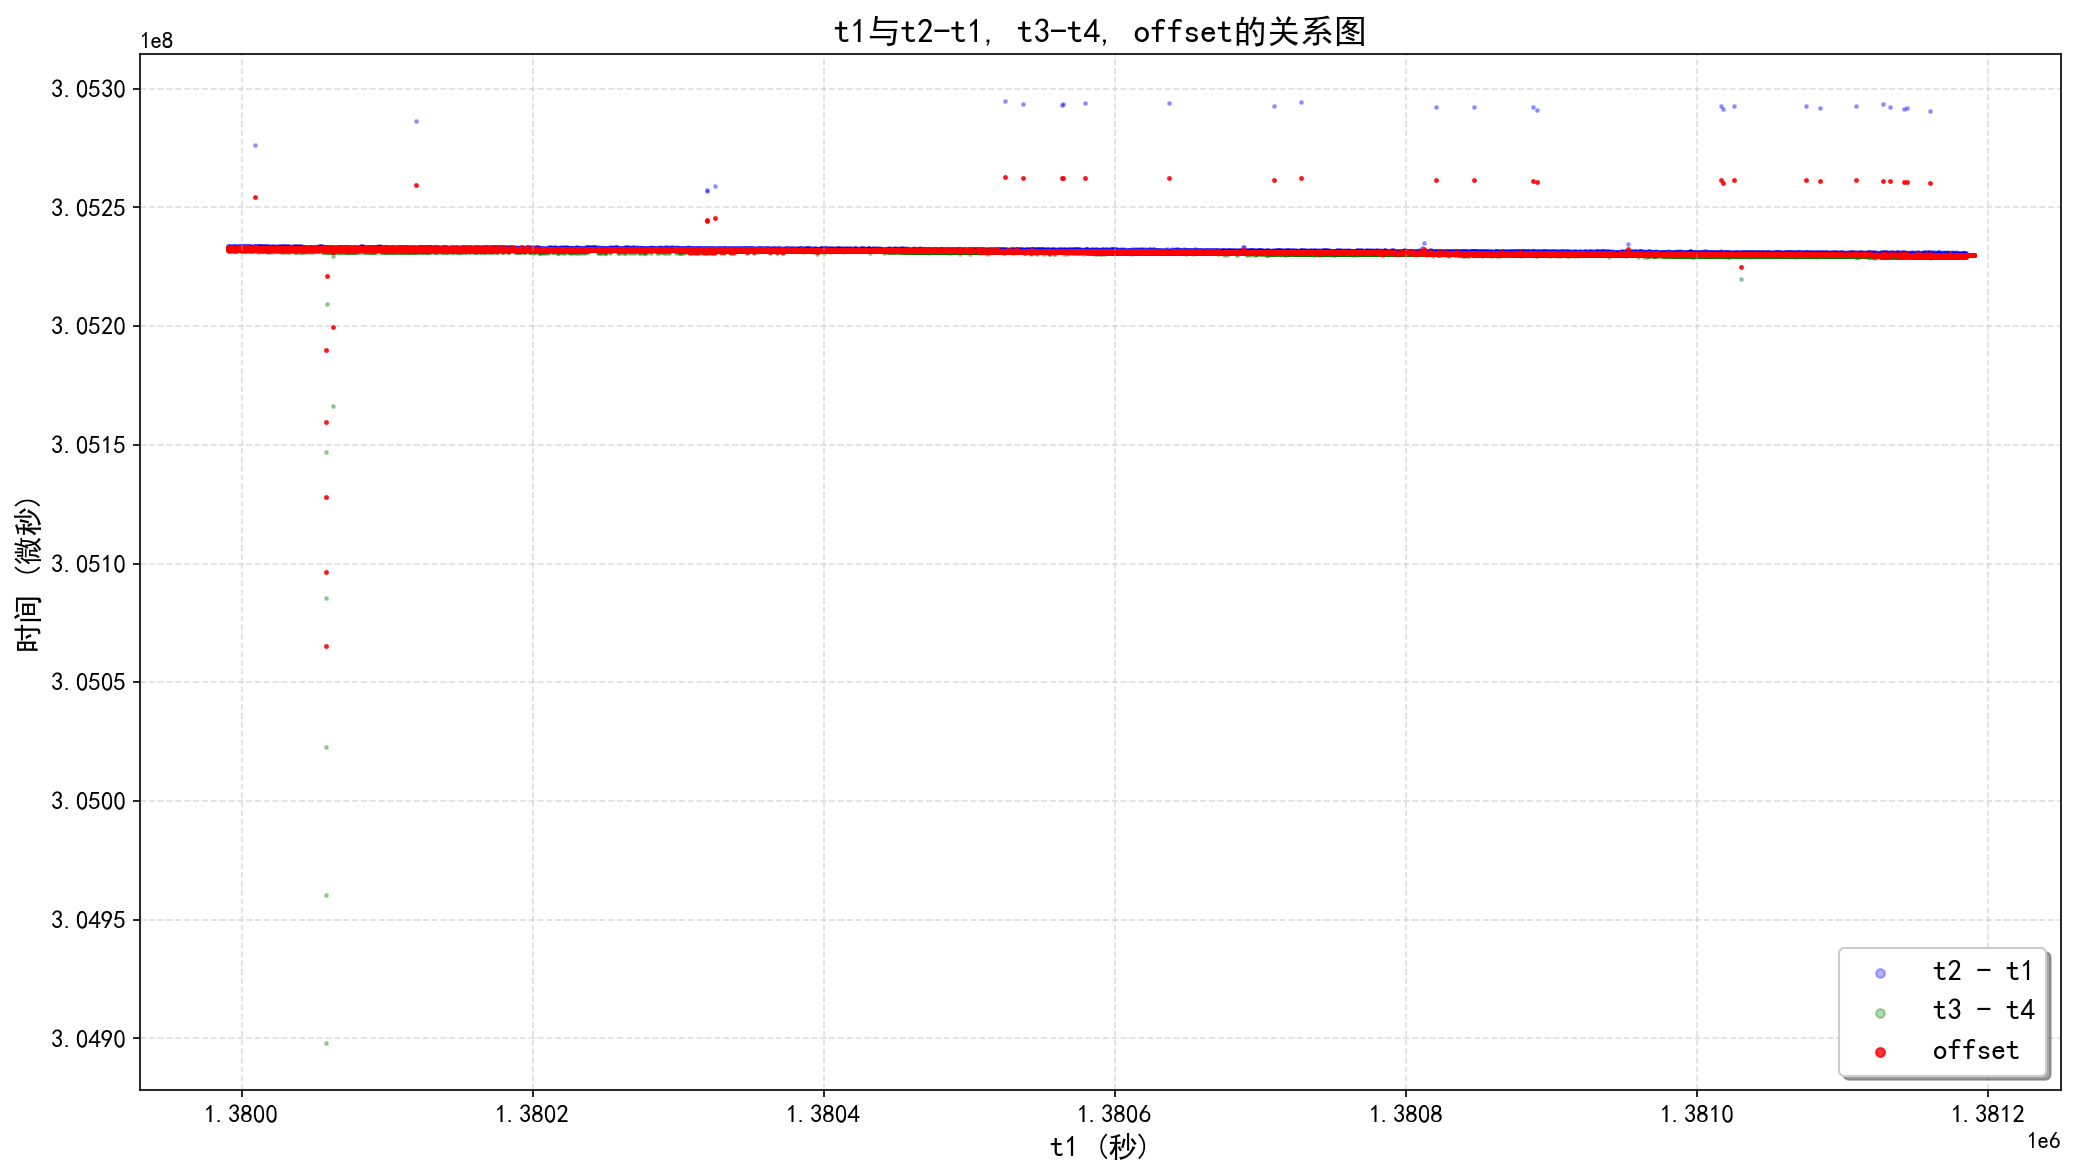

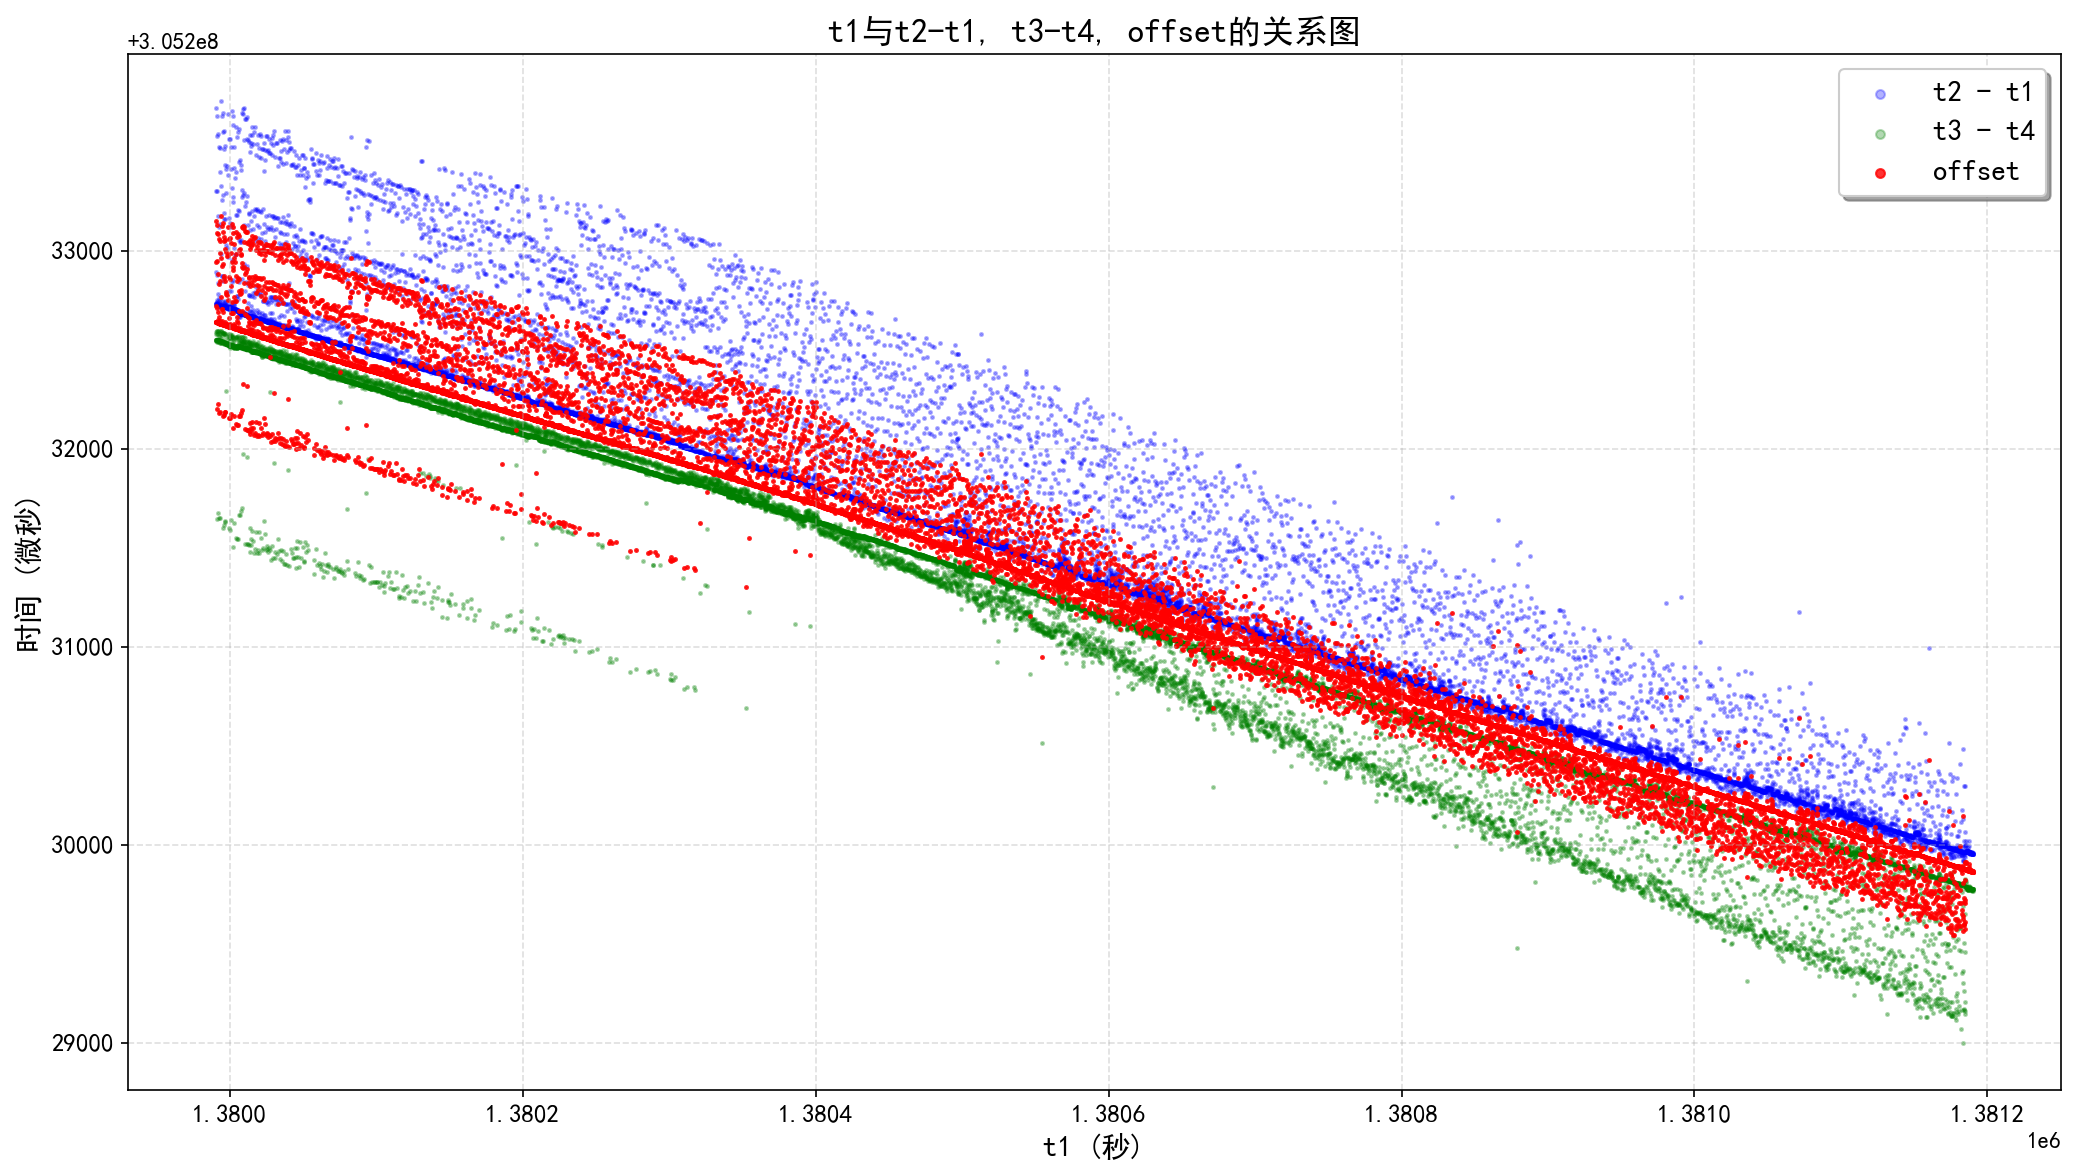

In [4]:
#画出来t1为横坐标，然后t2t1,t3t4还有raw_offset画在同一个图中
def plot_general_relationship(df):
    """绘制t1与t2-t1, t3-t4, offset,raw_offset,cal_offset的关系图"""
    plt.figure(figsize=(14, 8), dpi=150)
    
    plt.scatter(df['t1'], df['t2t1'], s=2, c='blue', alpha=0.3, label='t2 - t1')
    plt.scatter(df['t1'], df['t3t4'], s=2, c='green', alpha=0.3, label='t3 - t4') 
    # plt.scatter(df['t1'], df['raw_offset'], s=2, c='orange', alpha=0.7, label='raw_offset')
    # plt.scatter(df['t1'], df['cal_offset'], s=2, c='purple', alpha=0.7, label='cal_offset')
    plt.scatter(df['t1'], df['offset'], s=2, c='red', alpha=0.8, label='offset')
    
    plt.xlabel('t1 (秒)', fontsize=14)
    plt.ylabel('时间 (微秒)', fontsize=14)
    plt.title('t1与t2-t1, t3-t4, offset的关系图', fontsize=16, fontweight='bold')
    
    # 放大图例
    plt.legend(fontsize=14, markerscale=3, frameon=True, fancybox=True, shadow=True)
    
    # 增加网格透明度和样式
    plt.grid(True, alpha=0.4, linestyle='--')
    
    # 调整坐标轴刻度字体大小
    plt.tick_params(axis='both', which='major', labelsize=12)
    
    plt.tight_layout()
    plt.show()
plot_general_relationship(df_raw)
plot_general_relationship(df)



🔧 分段最小二乘回归拟合 (分段数: 10)...
   拟合数据点: 12,277 / 15,345 (80.0%)
   delay过滤范围: [83.9, 495.8] μs
   对应offset范围: [305229544.3, 305233090.8] μs
✅ LSQ拟合完成
   总体RMSE: 146.51 μs
   总体R²: 0.971973
   有效分段数: 10

📊 绘制LSQ拟合结果...


📁 SVG图像已保存至: c:\Git_Code\Clock_Sync\results\load_analysis_lsq\lsq_fitting_results.svg


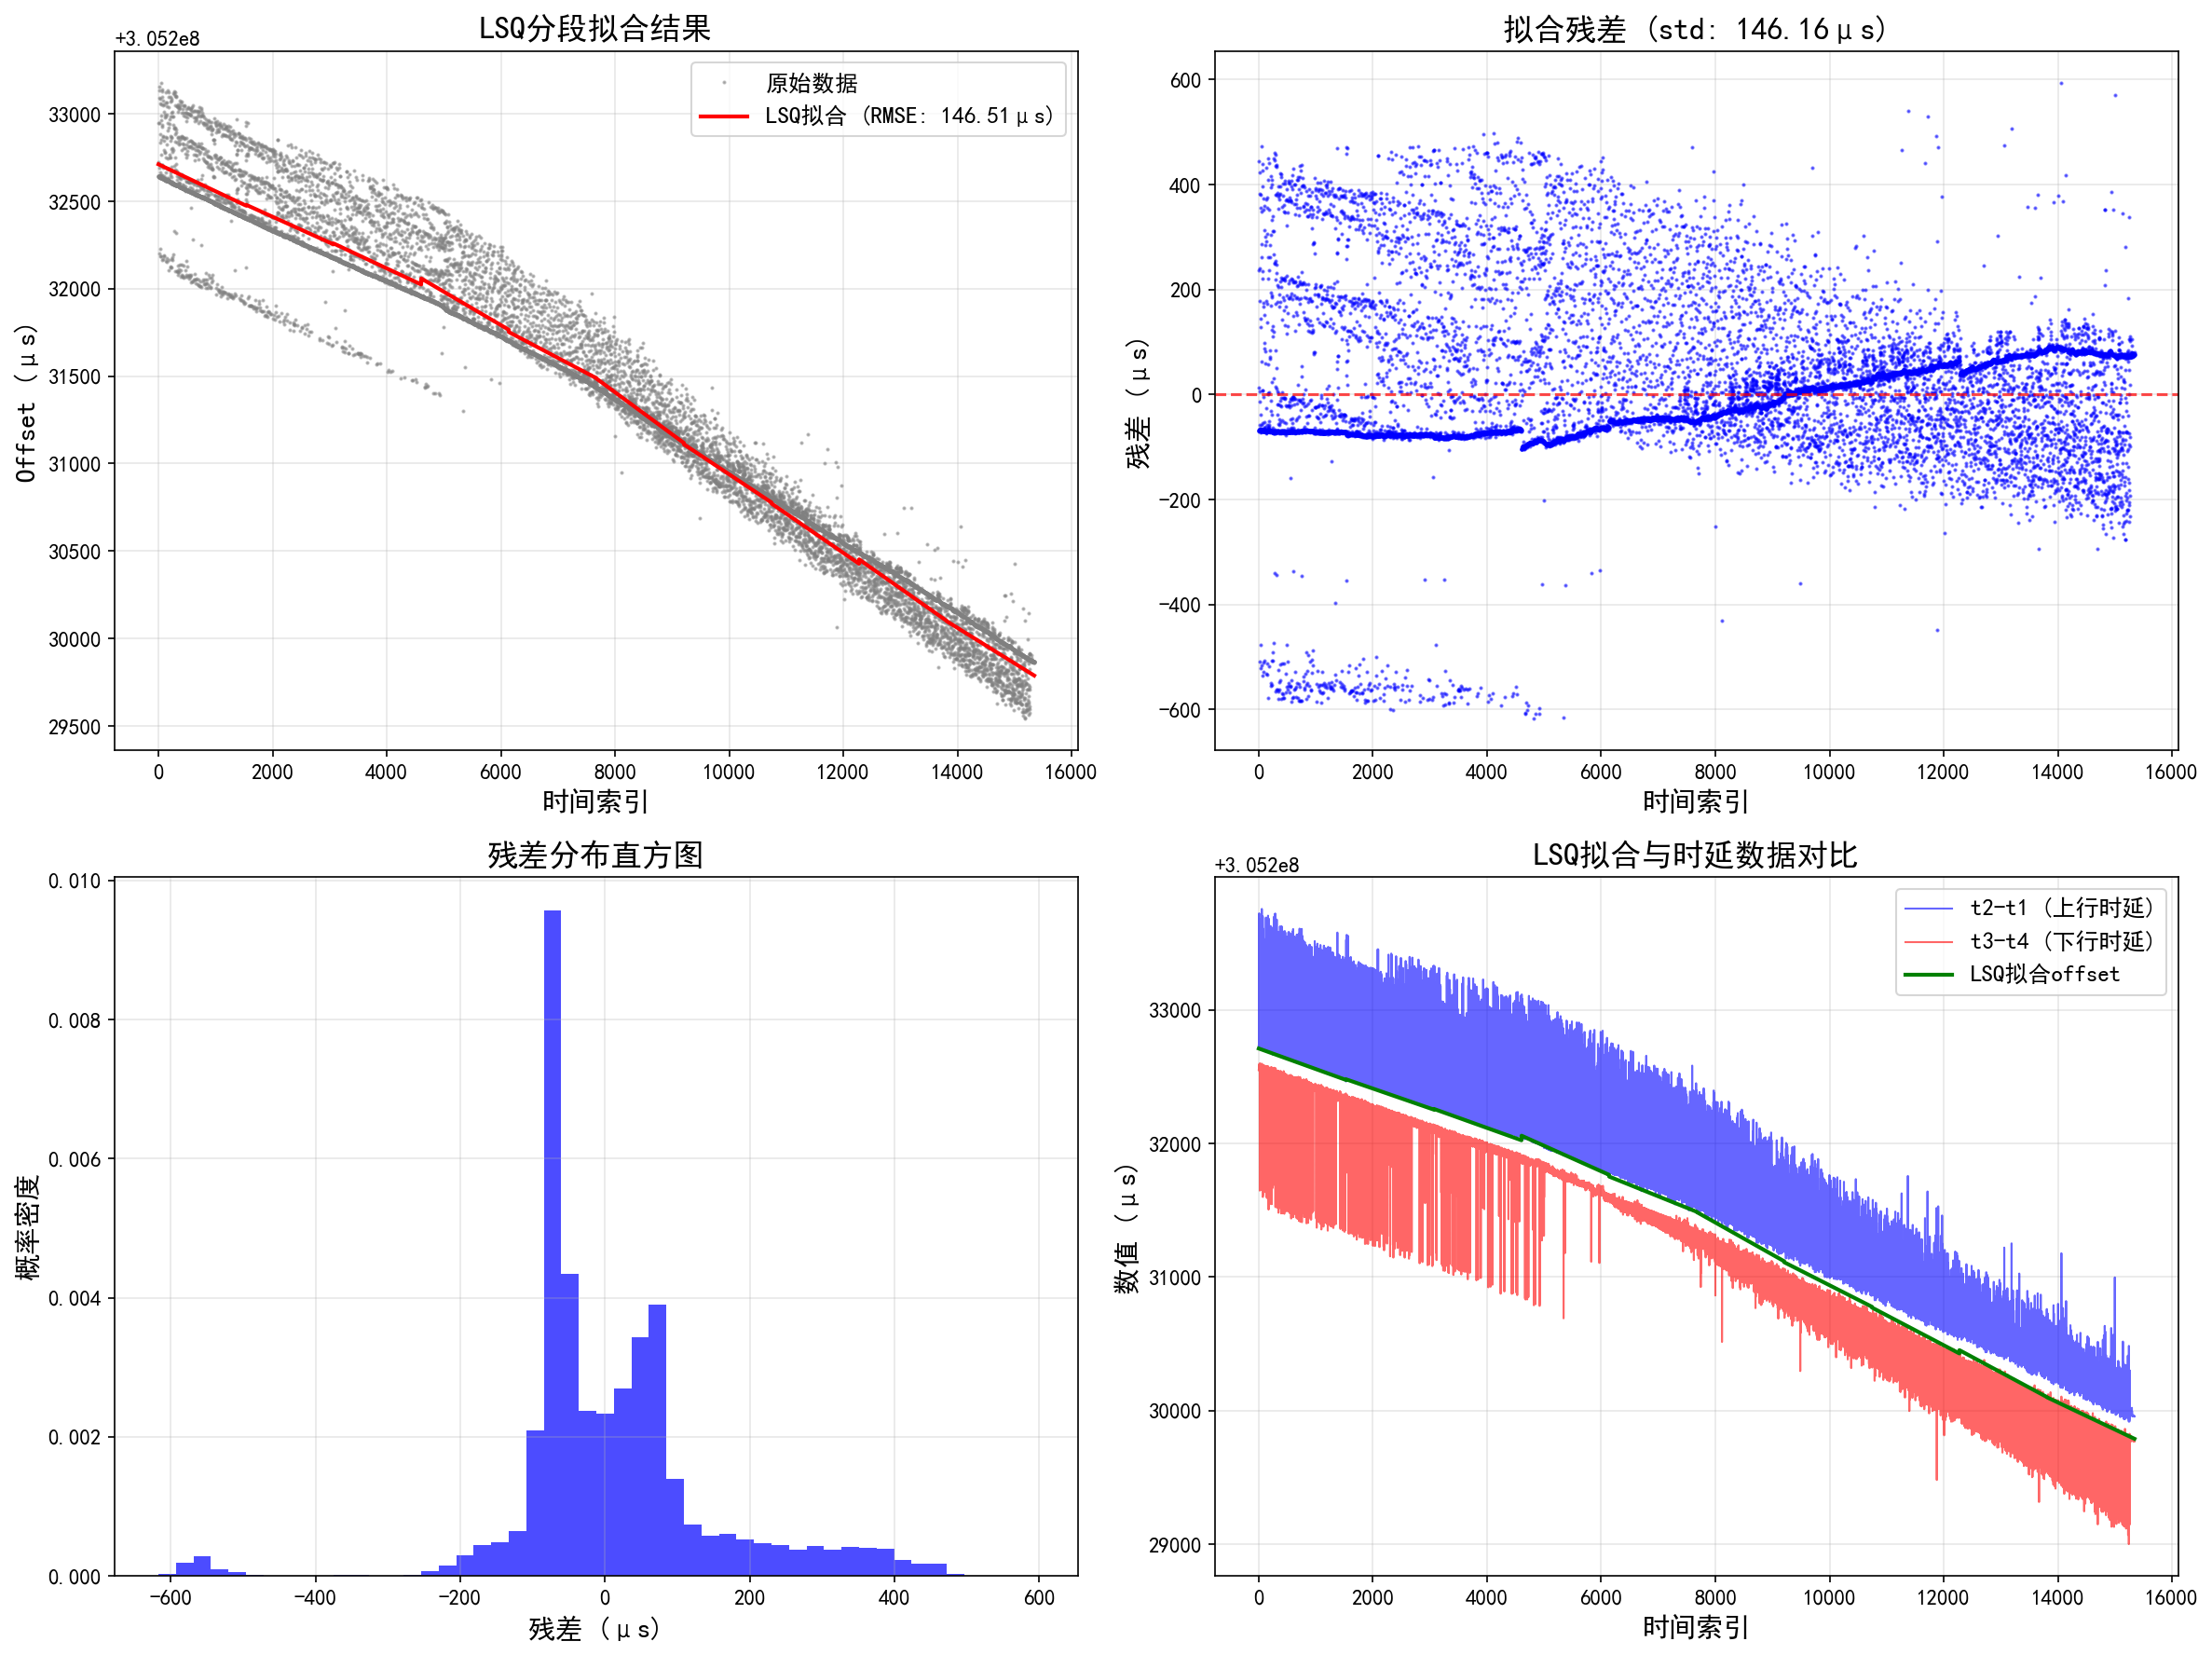


📈 LSQ拟合完成
   方法: LSQ
   RMSE: 146.51 μs
   R²: 0.971973
   分段数: 10
   拟合点数: 12,277


In [5]:
def piecewise_lsq_fit(df, piece_num=10, fit_lower_percent=0.01, fit_upper_percent=0.95):
    """分段最小二乘回归拟合raw_offset"""
    print(f"\n🔧 分段最小二乘回归拟合 (分段数: {piece_num})...")
    
    # 准备数据 - 使用时间索引作为x，offset作为y
    df = df.copy().reset_index(drop=True)
    x = np.arange(len(df))  # 时间索引
    y = df['offset'].values  #
    
    # 应用拟合范围过滤 - 按照delay进行分位过滤
    delay_lower = np.percentile(df['raw_delay'], fit_lower_percent * 100)
    delay_upper = np.percentile(df['raw_delay'], fit_upper_percent * 100)
    fit_mask = (df['raw_delay'] >= delay_lower) & (df['raw_delay'] <= delay_upper)
    
    x_fit = x[fit_mask]
    y_fit = y[fit_mask]
    
    print(f"   拟合数据点: {len(x_fit):,} / {len(x):,} ({len(x_fit)/len(x)*100:.1f}%)")
    print(f"   delay过滤范围: [{delay_lower:.1f}, {delay_upper:.1f}] μs")
    print(f"   对应offset范围: [{y_fit.min():.1f}, {y_fit.max():.1f}] μs")
    
    # 分段拟合
    x_min, x_max = x_fit.min(), x_fit.max()
    piece_bounds = np.linspace(x_min, x_max, piece_num + 1)
    
    # 存储拟合结果
    piece_results = []
    y_pred = np.zeros_like(y)
    
    for i in range(piece_num):
        # 分段数据 - 用于拟合
        if i == piece_num - 1:  # 最后一段包含右边界
            piece_mask = (x_fit >= piece_bounds[i]) & (x_fit <= piece_bounds[i + 1])
        else:
            piece_mask = (x_fit >= piece_bounds[i]) & (x_fit < piece_bounds[i + 1])
        
        x_piece = x_fit[piece_mask]
        y_piece = y_fit[piece_mask]
        
        if len(x_piece) < 2:
            continue
            
        # 线性拟合
        coeffs = np.polyfit(x_piece, y_piece, 1)
        slope, intercept = coeffs
        
        # 预测整个段的值 - 用所有的x
        if i == piece_num - 1:  # 最后一段包含右边界
            full_piece_mask = (x >= piece_bounds[i]) & (x <= piece_bounds[i + 1])
        else:
            full_piece_mask = (x >= piece_bounds[i]) & (x < piece_bounds[i + 1])
        
        y_pred[full_piece_mask] = slope * x[full_piece_mask] + intercept
        
        # 保存结果
        piece_results.append({
            'piece': i,
            'x_range': (piece_bounds[i], piece_bounds[i + 1]),
            'slope': slope,
            'intercept': intercept,
            'n_points': len(x_piece),
            'rmse': np.sqrt(np.mean((y_piece - (slope * x_piece + intercept))**2))
        })
    # 计算整体拟合质量
    overall_rmse = np.sqrt(np.mean((y - y_pred)**2))
    overall_r2 = 1 - np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2)
    
    print(f"✅ LSQ拟合完成")
    print(f"   总体RMSE: {overall_rmse:.2f} μs")
    print(f"   总体R²: {overall_r2:.6f}")
    print(f"   有效分段数: {len(piece_results)}")
    
    return {
        'method': 'LSQ',
        'y_pred': y_pred,
        'rmse': overall_rmse,
        'r2': overall_r2,
        'piece_results': piece_results,
        'piece_num': piece_num,
        'fit_points': len(x_fit)
    }

def plot_lsq_results(df, lsq_result, save_svg=True):
    """绘制LSQ拟合结果"""
    print(f"\n📊 绘制LSQ拟合结果...")
    
    # 准备数据
    x = np.arange(len(df))
    y_original = df['offset'].values
    y_pred = lsq_result['y_pred']
    
    # 计算残差
    residuals = y_original - y_pred
    
    # 创建图形 - 2x2布局，更大尺寸
    plt.figure(figsize=(16, 12))
    
    # 子图1: 原始数据和拟合结果
    plt.subplot(2, 2, 1)
    plt.plot(x, y_original, 'o', color='gray', alpha=0.5, markersize=1, label='原始数据')
    plt.plot(x, y_pred, '-', color='red', linewidth=2, label=f'LSQ拟合 (RMSE: {lsq_result["rmse"]:.2f}μs)')
    plt.xlabel('时间索引')
    plt.ylabel('Offset (μs)')
    plt.title('LSQ分段拟合结果')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 子图2: 残差图
    plt.subplot(2, 2, 2)
    plt.plot(x, residuals, 'o', color='blue', alpha=0.5, markersize=1)
    plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)
    plt.xlabel('时间索引')
    plt.ylabel('残差 (μs)')
    plt.title(f'拟合残差 (std: {np.std(residuals):.2f}μs)')
    plt.grid(True, alpha=0.3)
    
    # 子图3: 残差分布
    plt.subplot(2, 2, 3)
    plt.hist(residuals, bins=50, alpha=0.7, color='blue', density=True)
    plt.xlabel('残差 (μs)')
    plt.ylabel('概率密度')
    plt.title('残差分布直方图')
    plt.grid(True, alpha=0.3)
    
    # 子图4: LSQ拟合结果与t2t1、t3t4的关系
    plt.subplot(2, 2, 4)
    plt.plot(x, df['t2t1'], 'b-', alpha=0.6, linewidth=1, label='t2-t1 (上行时延)')
    plt.plot(x, df['t3t4'], 'r-', alpha=0.6, linewidth=1, label='t3-t4 (下行时延)')
    plt.plot(x, y_pred, 'g-', linewidth=2, label='LSQ拟合offset')
    plt.xlabel('时间索引')
    plt.ylabel('数值 (μs)')
    plt.title('LSQ拟合与时延数据对比')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # 保存SVG格式
    if save_svg:
        svg_path = r"c:\Git_Code\Clock_Sync\results\load_analysis_lsq\lsq_fitting_results.svg"
        os.makedirs(os.path.dirname(svg_path), exist_ok=True)
        plt.savefig(svg_path, format='svg', bbox_inches='tight', dpi=300)
        print(f"📁 SVG图像已保存至: {svg_path}")
    
    plt.show()

# 执行LSQ拟合
lsq_result = piecewise_lsq_fit(df, piece_num=10, fit_lower_percent=0.1, fit_upper_percent=0.9)

# 绘制结果
plot_lsq_results(df, lsq_result)

print(f"\n📈 LSQ拟合完成")
print(f"   方法: {lsq_result['method']}")
print(f"   RMSE: {lsq_result['rmse']:.2f} μs")
print(f"   R²: {lsq_result['r2']:.6f}")
print(f"   分段数: {lsq_result['piece_num']}")
print(f"   拟合点数: {lsq_result['fit_points']:,}")



🔧 分段SVR拟合 (分段数: 10, kernel: linear)...
   拟合数据点: 6,141 / 15,345 (40.0%)
   delay过滤范围: [83.9, 97.3] μs
   对应offset范围: [305229850.9, 305232666.4] μs
   分段 1: [0, 1534] 784 点, RMSE=7.17, R²=0.9891, 支持向量=11
   分段 2: [1534, 3069] 845 点, RMSE=4.35, R²=0.9956, 支持向量=7
   分段 3: [3069, 4603] 851 点, RMSE=4.84, R²=0.9938, 支持向量=3
   分段 4: [4603, 6138] 665 点, RMSE=8.72, R²=0.9861, 支持向量=67
   分段 5: [6138, 7672] 747 点, RMSE=8.86, R²=0.9828, 支持向量=50
   分段 6: [7672, 9206] 447 点, RMSE=13.81, R²=0.9785, 支持向量=134
   分段 7: [9206, 10741] 487 点, RMSE=11.97, R²=0.9806, 支持向量=86
   分段 8: [10741, 12275] 430 点, RMSE=12.34, R²=0.9830, 支持向量=80
   分段 9: [12275, 13810] 429 点, RMSE=10.65, R²=0.9858, 支持向量=53
   分段 10: [13810, 15344] 456 点, RMSE=12.75, R²=0.9845, 支持向量=85
✅ 分段SVR拟合完成
   总体RMSE: 159.51 μs
   总体R²: 0.966779
   总拟合时间: 0.08s
   总支持向量数: 576
   有效分段数: 10
📁 SVG图像已保存至: c:\Git_Code\Clock_Sync\results\load_analysis_lsq\piecewise_svr_fitting_results.svg


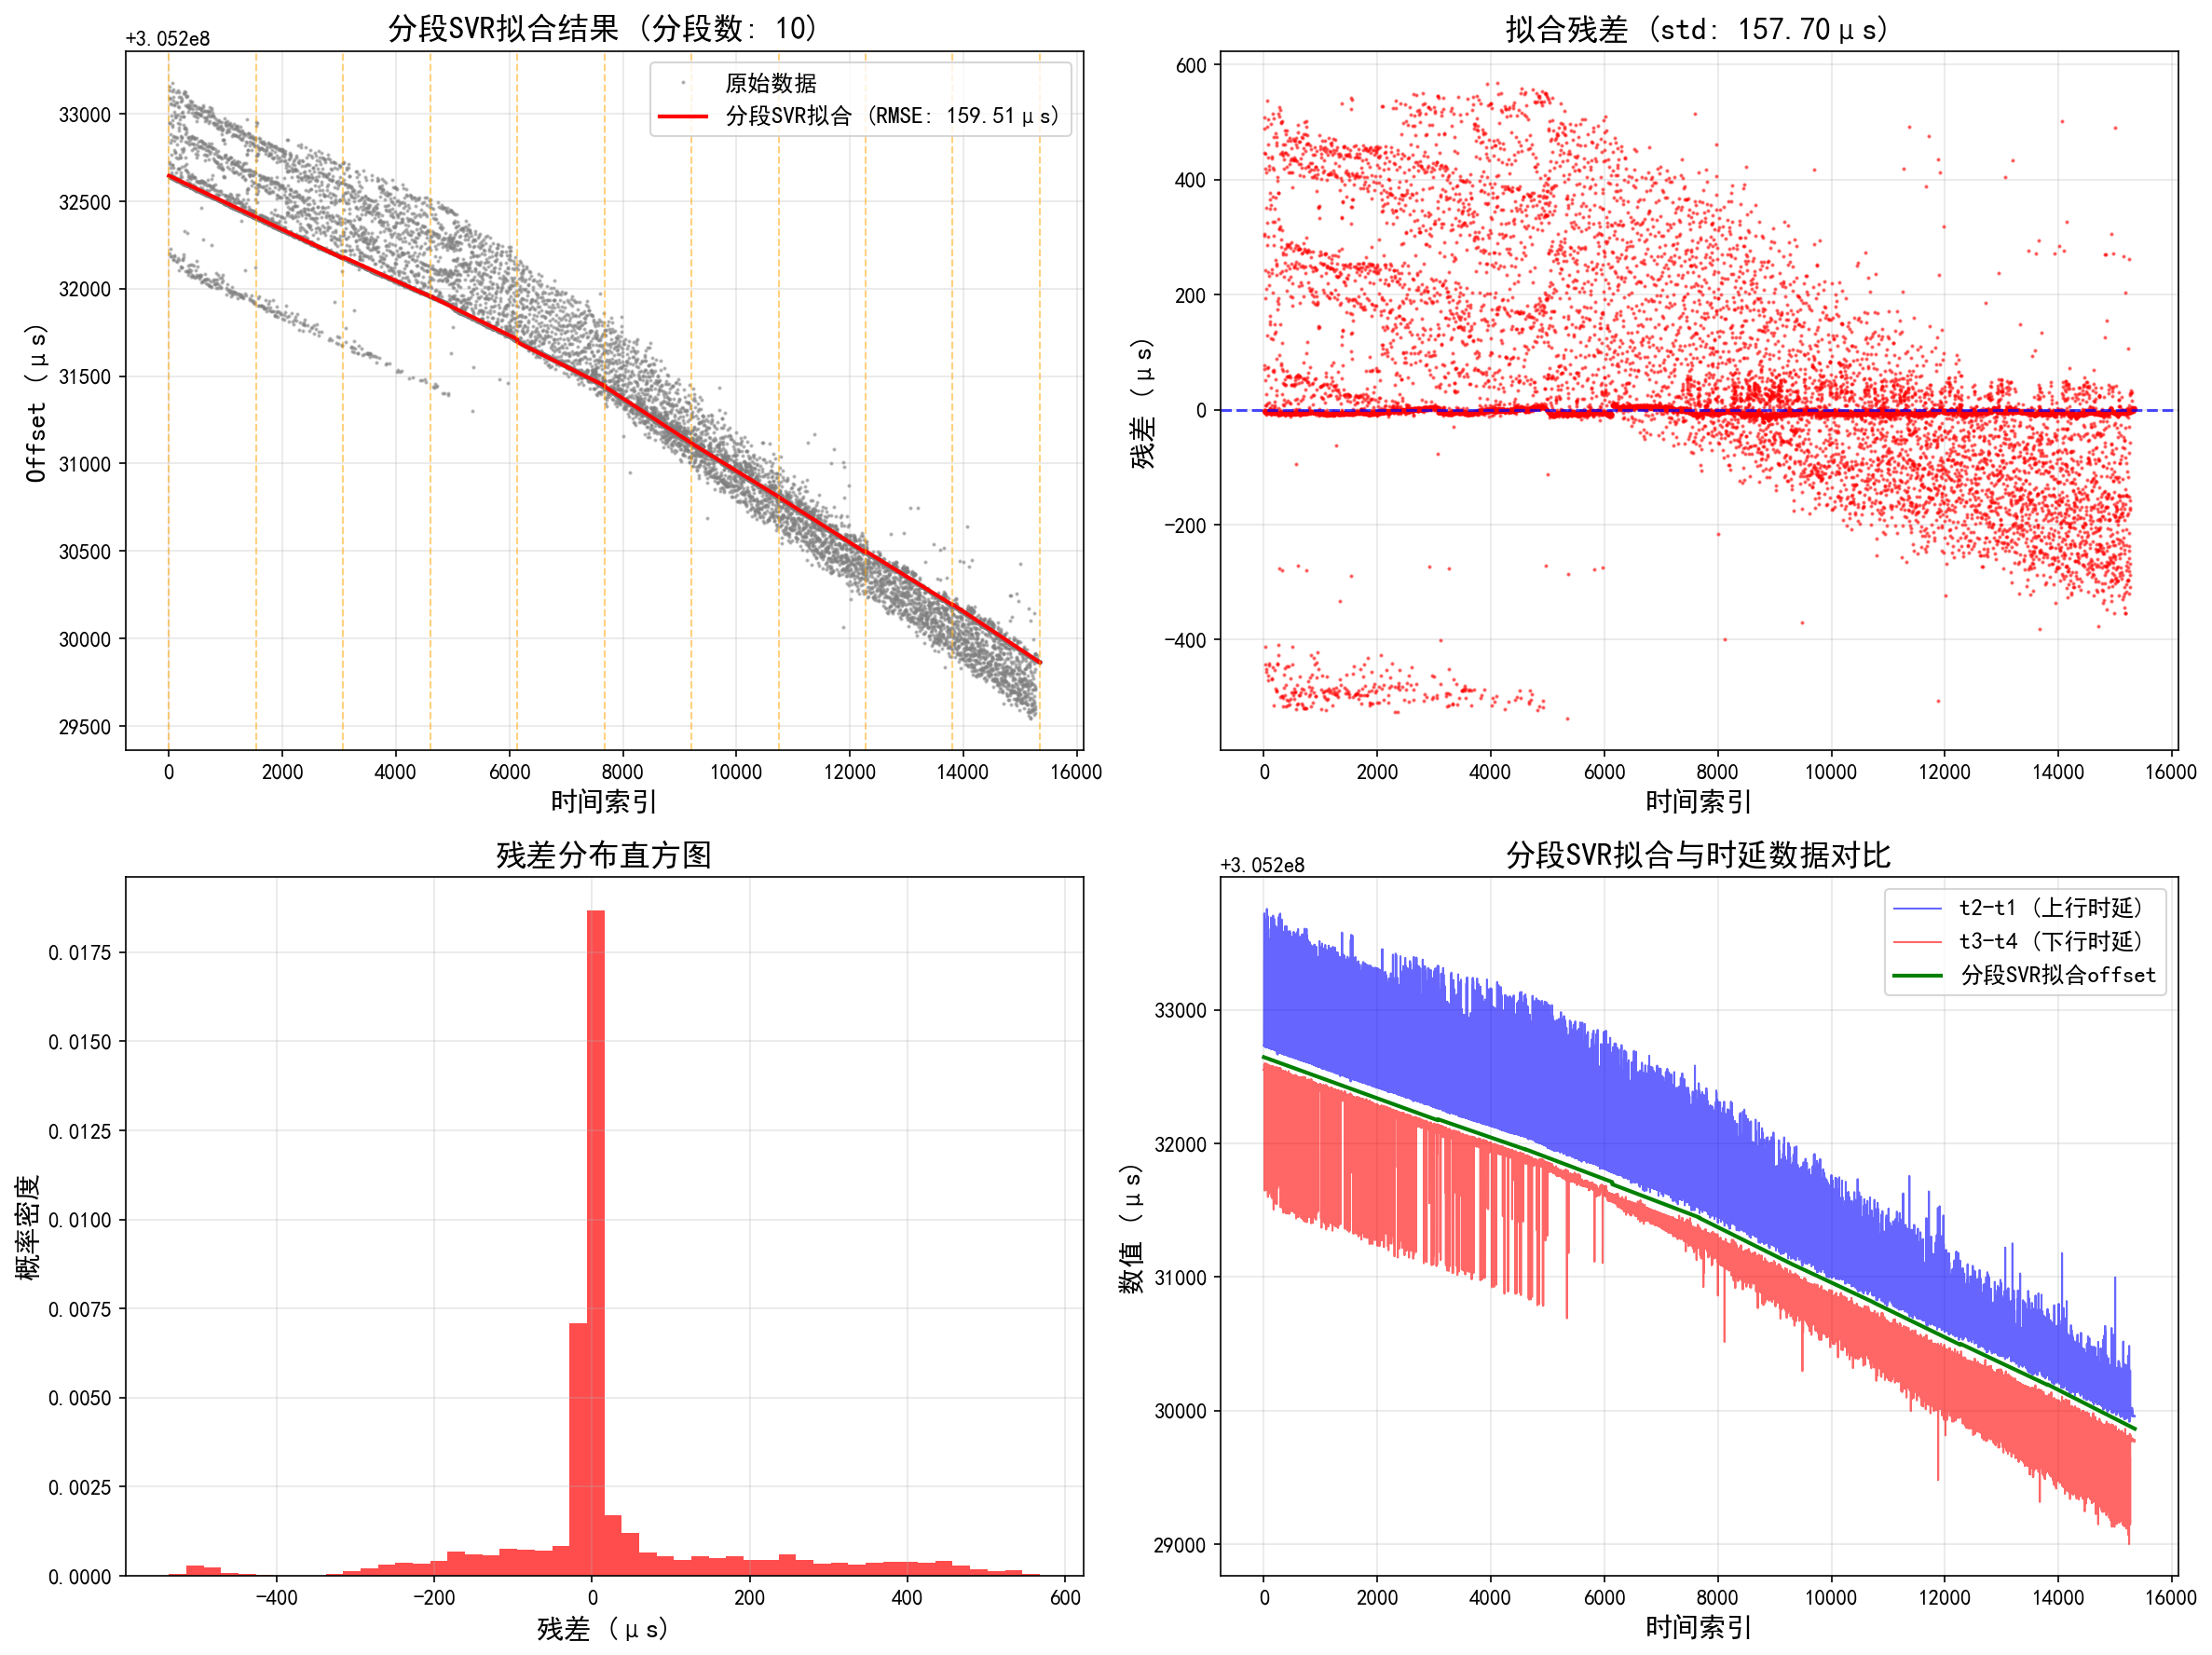

In [6]:
def piecewise_svr_fit(df, piece_num=10, fit_lower_percent=0.01, fit_upper_percent=0.7, 
                      C=1.0, gamma='scale', kernel='rbf', epsilon=5):
    """分段SVR拟合"""
    print(f"\n🔧 分段SVR拟合 (分段数: {piece_num}, kernel: {kernel})...")
    
    # 准备数据 - 使用时间索引作为x，offset作为y
    df = df.copy().reset_index(drop=True)
    x = np.arange(len(df))  # 时间索引
    y = df['offset'].values
    
    # 应用拟合范围过滤 - 按照delay进行分位过滤
    delay_lower = np.percentile(df['raw_delay'], fit_lower_percent * 100)
    delay_upper = np.percentile(df['raw_delay'], fit_upper_percent * 100)
    fit_mask = (df['raw_delay'] >= delay_lower) & (df['raw_delay'] <= delay_upper)
    
    x_fit = x[fit_mask]
    y_fit = y[fit_mask]
    
    print(f"   拟合数据点: {len(x_fit):,} / {len(x):,} ({len(x_fit)/len(x)*100:.1f}%)")
    print(f"   delay过滤范围: [{delay_lower:.1f}, {delay_upper:.1f}] μs")
    print(f"   对应offset范围: [{y_fit.min():.1f}, {y_fit.max():.1f}] μs")
    
    # 分段拟合
    x_min, x_max = x_fit.min(), x_fit.max()
    piece_bounds = np.linspace(x_min, x_max, piece_num + 1)
    
    # 存储拟合结果
    piece_results = []
    y_pred = np.zeros_like(y)
    total_fit_time = 0
    total_support_vectors = 0
    
    for i in range(piece_num):
        # 分段数据 - 用于拟合
        if i == piece_num - 1:  # 最后一段包含右边界
            piece_mask = (x_fit >= piece_bounds[i]) & (x_fit <= piece_bounds[i + 1])
        else:
            piece_mask = (x_fit >= piece_bounds[i]) & (x_fit < piece_bounds[i + 1])
        
        x_piece = x_fit[piece_mask]
        y_piece = y_fit[piece_mask]
        
        if len(x_piece) < 5:  # 数据点太少，跳过
            print(f"   分段 {i+1}: 数据点太少 ({len(x_piece)}), 跳过")
            continue
        
        # 创建SVR模型
        svr_model = SVR(kernel=kernel, C=C, gamma=gamma, epsilon=epsilon, max_iter=50000)
        
        # 拟合
        start_time = time.time()
        try:
            svr_model.fit(x_piece.reshape(-1, 1), y_piece)
            fit_time = time.time() - start_time
            total_fit_time += fit_time
            
            # 预测整个段的值 - 用所有的x
            if i == piece_num - 1:  # 最后一段包含右边界
                full_piece_mask = (x >= piece_bounds[i]) & (x <= piece_bounds[i + 1])
            else:
                full_piece_mask = (x >= piece_bounds[i]) & (x < piece_bounds[i + 1])
            
            y_pred[full_piece_mask] = svr_model.predict(x[full_piece_mask].reshape(-1, 1))
            
            # 计算分段评估指标
            piece_rmse = np.sqrt(np.mean((y_piece - svr_model.predict(x_piece.reshape(-1, 1)))**2))
            piece_r2 = 1 - np.sum((y_piece - svr_model.predict(x_piece.reshape(-1, 1)))**2) / np.sum((y_piece - np.mean(y_piece))**2)
            
            n_support = len(svr_model.support_)
            total_support_vectors += n_support
            
            # 保存结果
            piece_results.append({
                'piece': i,
                'x_range': (piece_bounds[i], piece_bounds[i + 1]),
                'n_points': len(x_piece),
                'rmse': piece_rmse,
                'r2': piece_r2,
                'fit_time': fit_time,
                'n_support': n_support,
                'model': svr_model
            })
            
            print(f"   分段 {i+1}: [{piece_bounds[i]:.0f}, {piece_bounds[i+1]:.0f}] {len(x_piece)} 点, RMSE={piece_rmse:.2f}, R²={piece_r2:.4f}, 支持向量={n_support}")
            
        except Exception as e:
            print(f"   分段 {i+1}: 拟合失败 - {str(e)}")
            continue
    
    # 计算整体拟合质量
    overall_rmse = np.sqrt(np.mean((y - y_pred)**2))
    overall_r2 = 1 - np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2)
    
    print(f"✅ 分段SVR拟合完成")
    print(f"   总体RMSE: {overall_rmse:.2f} μs")
    print(f"   总体R²: {overall_r2:.6f}")
    print(f"   总拟合时间: {total_fit_time:.2f}s")
    print(f"   总支持向量数: {total_support_vectors}")
    print(f"   有效分段数: {len(piece_results)}")
    
    return {
        'method': 'Piecewise SVR',
        'y_pred': y_pred,
        'rmse': overall_rmse,
        'r2': overall_r2,
        'fit_time': total_fit_time,
        'kernel': kernel,
        'n_support': total_support_vectors,
        'fit_points': len(x_fit),
        'piece_results': piece_results,
        'piece_num': piece_num
    }
def plot_piecewise_svr_results(df, piecewise_svr_result, save_svg=True):
    """绘制分段SVR拟合结果"""
    
    # 准备数据
    x = np.arange(len(df))
    y_original = df['offset'].values
    y_pred = piecewise_svr_result['y_pred']
    
    # 计算残差
    residuals = y_original - y_pred
    
    # 创建图形 - 2x2布局，更大尺寸
    plt.figure(figsize=(16, 12))
    
    # 子图1: 原始数据和拟合结果
    plt.subplot(2, 2, 1)
    plt.plot(x, y_original, 'o', color='gray', alpha=0.5, markersize=1, label='原始数据')
    plt.plot(x, y_pred, '-', color='red', linewidth=2, label=f'分段SVR拟合 (RMSE: {piecewise_svr_result["rmse"]:.2f}μs)')
    
    # 绘制分段边界
    if 'piece_results' in piecewise_svr_result:
        for piece_result in piecewise_svr_result['piece_results']:
            x_start, x_end = piece_result['x_range']
            plt.axvline(x=x_start, color='orange', linestyle='--', alpha=0.5, linewidth=1)
        plt.axvline(x=piecewise_svr_result['piece_results'][-1]['x_range'][1], color='orange', linestyle='--', alpha=0.5, linewidth=1)
    
    plt.xlabel('时间索引')
    plt.ylabel('Offset (μs)')
    plt.title(f'分段SVR拟合结果 (分段数: {piecewise_svr_result["piece_num"]})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 子图2: 残差图
    plt.subplot(2, 2, 2)
    plt.plot(x, residuals, 'o', color='red', alpha=0.5, markersize=1)
    plt.axhline(y=0, color='blue', linestyle='--', alpha=0.7)
    plt.xlabel('时间索引')
    plt.ylabel('残差 (μs)')
    plt.title(f'拟合残差 (std: {np.std(residuals):.2f}μs)')
    plt.grid(True, alpha=0.3)
    
    # 子图3: 残差分布
    plt.subplot(2, 2, 3)
    plt.hist(residuals, bins=50, alpha=0.7, color='red', density=True)
    plt.xlabel('残差 (μs)')
    plt.ylabel('概率密度')
    plt.title('残差分布直方图')
    plt.grid(True, alpha=0.3)
    
    # 子图4: 分段SVR拟合结果与t2t1、t3t4的关系
    plt.subplot(2, 2, 4)
    plt.plot(x, df['t2t1'], 'b-', alpha=0.6, linewidth=1, label='t2-t1 (上行时延)')
    plt.plot(x, df['t3t4'], 'r-', alpha=0.6, linewidth=1, label='t3-t4 (下行时延)')
    plt.plot(x, y_pred, 'g-', linewidth=2, label='分段SVR拟合offset')
    plt.xlabel('时间索引')
    plt.ylabel('数值 (μs)')
    plt.title('分段SVR拟合与时延数据对比')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # 保存SVG格式
    if save_svg:
        svg_path = r"c:\Git_Code\Clock_Sync\results\load_analysis_lsq\piecewise_svr_fitting_results.svg"
        os.makedirs(os.path.dirname(svg_path), exist_ok=True)
        plt.savefig(svg_path, format='svg', bbox_inches='tight', dpi=300)
        print(f"📁 SVG图像已保存至: {svg_path}")
    
    plt.show()

# 执行SVR拟合
# 执行分段SVR拟合
piecewise_svr_result = piecewise_svr_fit(df, piece_num=10, kernel='linear', C=0.01, gamma='scale', fit_lower_percent=0.1,fit_upper_percent=0.5,epsilon=10)

# 绘制结果
plot_piecewise_svr_results(df, piecewise_svr_result)


🚀 使用 t1 + delay 特征训练 HUYGENS-style Linear SVM
分类正确率: 1.00
决策边界斜率: -0.2574
决策边界截距: -0.0122


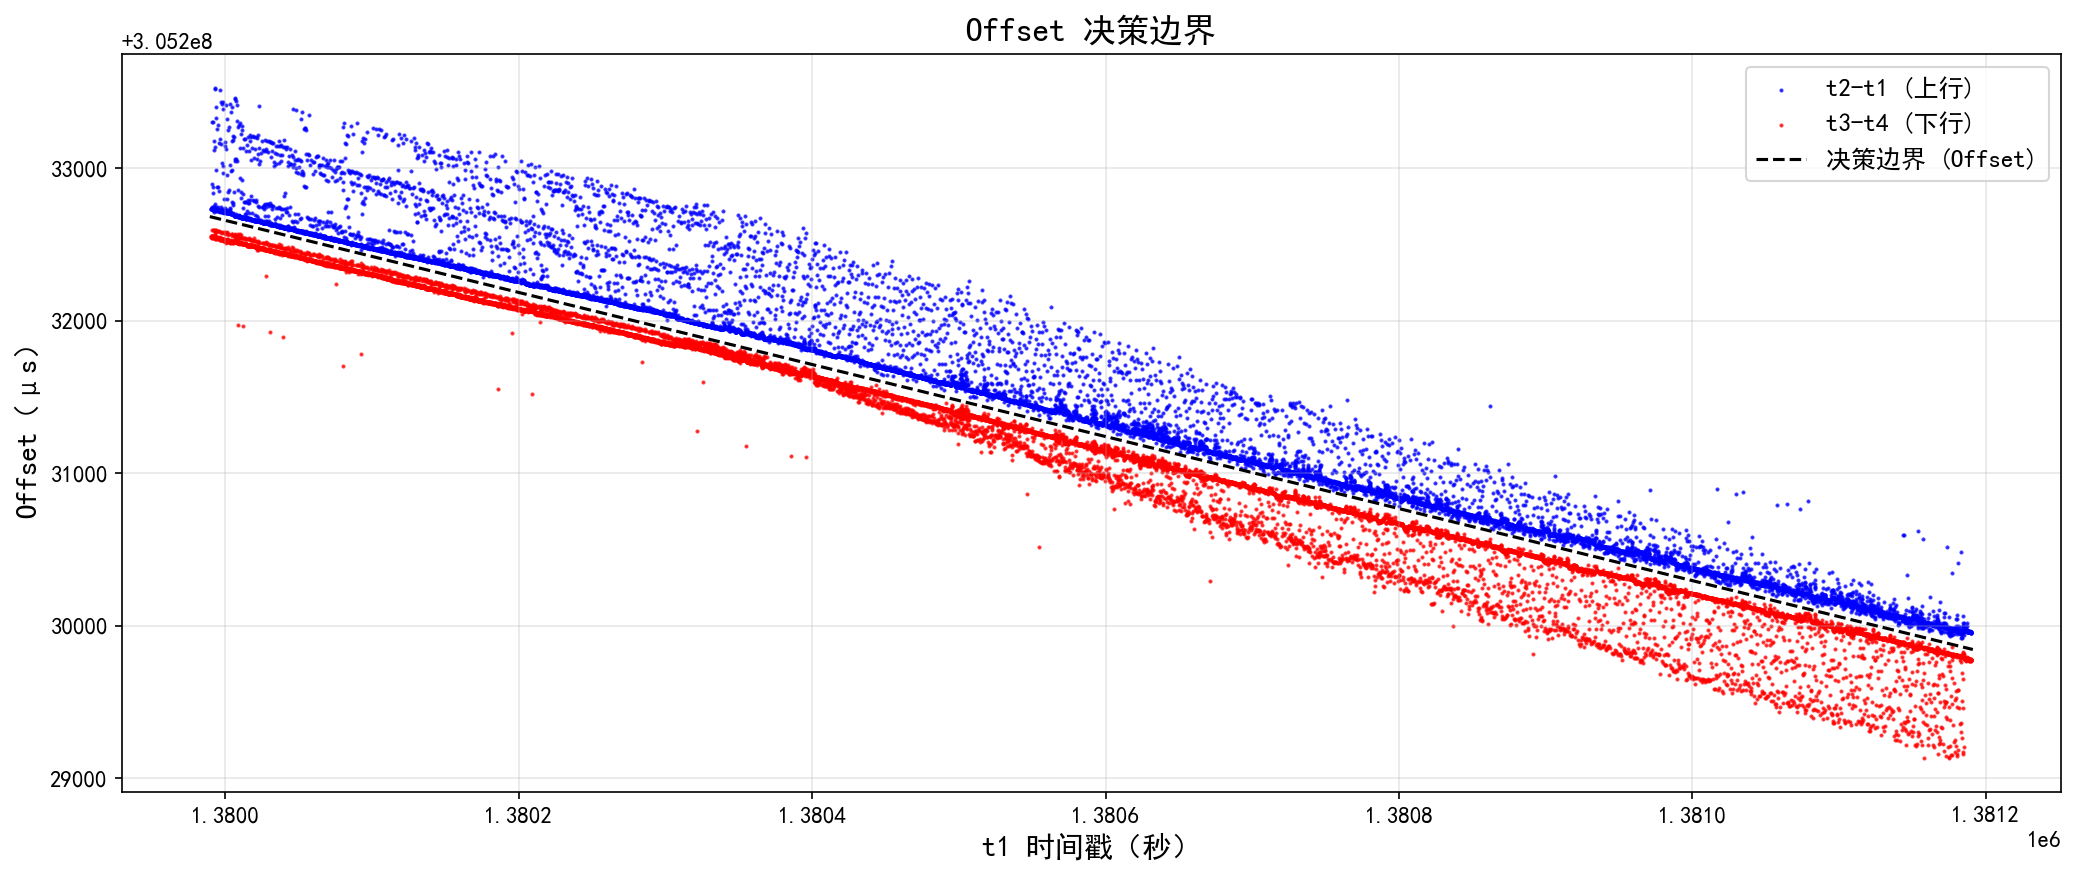

In [7]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
def huygens_svm_with_t1(df, C=1.0):
    """
    使用 HUYGENS 风格的 Linear SVM 拟合 offset 中线，特征为 [t1, delay]
    """
    print("🚀 使用 t1 + delay 特征训练 HUYGENS-style Linear SVM")
    # df = apply_percentile_filter(df,0.05,0.9)
    # 准备数据
    t1 = df['t1'].values.reshape(-1, 1)
    y_up = df['t2t1'].values
    y_down = df['t3t4'].values
    y_mid = (y_up + y_down) / 2

    # 拼接训练数据：上行为类1，下行为类0
    X = np.concatenate([
        np.column_stack([t1, y_up]),
        np.column_stack([t1, y_down])
    ])
    y = np.concatenate([
        np.ones_like(y_up),    # 上行为正类
        np.zeros_like(y_down)  # 下行为负类
    ])

    # 标准化特征
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X) 
    # 拟合 Linear SVM 分类器
    clf = SVC(kernel='linear', C=C)
    clf.fit(X_scaled, y)

    # 计算分类正确率
    accuracy = clf.score(X_scaled, y)
    print(f"分类正确率: {accuracy:.2f}")
    # 提取决策边界的斜率和截距
    w = clf.coef_[0]  # 权重向量
    b = clf.intercept_[0]  # 截距
    slope = -w[0] / w[1]  # 斜率
    intercept = -b / w[1]  # 截距
    print(f"决策边界斜率: {slope:.4f}")
    print(f"决策边界截距: {intercept:.4f}")

    return clf, scaler,slope, intercept

def plot_decision_boundary_with_offset(df, scaler, slope, intercept, title="Offset 决策边界"):
    """
    绘制 offset 关于 t1 的决策边界
    """
    # 获取标准化参数
    t1_mean, t1_std = scaler.mean_[0], scaler.scale_[0]
    delay_mean, delay_std = scaler.mean_[1], scaler.scale_[1]
    df = apply_percentile_filter(df,0.05,0.8)
    # 反标准化斜率和截距
    slope_original = slope * (delay_std / t1_std)
    intercept_original = intercept * delay_std + delay_mean - slope_original * t1_mean

    # 准备数据
    t1 = df['t1'].values
    y_up = df['t2t1'].values
    y_down = df['t3t4'].values
    y_offset = (y_up + y_down) / 2

    # 绘制数据点
    plt.figure(figsize=(14, 6))
    # plt.scatter(t1, y_offset, color='purple', label='Offset (中线)', alpha=0.7, s=1)
    plt.scatter(t1, y_up, color='blue', label='t2-t1 (上行)', alpha=0.7, s=1)
    plt.scatter(t1, y_down, color='red', label='t3-t4 (下行)', alpha=0.7, s=1)

    # 绘制决策边界
    t1_range = np.linspace(t1.min() - 1, t1.max() + 1, 100)
    decision_boundary = slope_original * t1_range + intercept_original
    plt.plot(t1_range, decision_boundary, color='black', linestyle='--', label='决策边界 (Offset)')

    plt.title(title)
    plt.xlabel("t1 时间戳（秒）")
    plt.ylabel("Offset（μs）")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 执行 SVM 训练并绘制决策边界
clf, scaler,slope,intercept = huygens_svm_with_t1(df_raw, C=10)
plot_decision_boundary_with_offset(df_raw, scaler, slope, intercept)

决策边界评估结果:
  RMSE: 2167.19 μs
  R²: 0.111713
  残差标准差: 2166.85 μs
📁 SVG图像已保存至: c:\Git_Code\Clock_Sync\results\decision_boundary_evaluation.svg


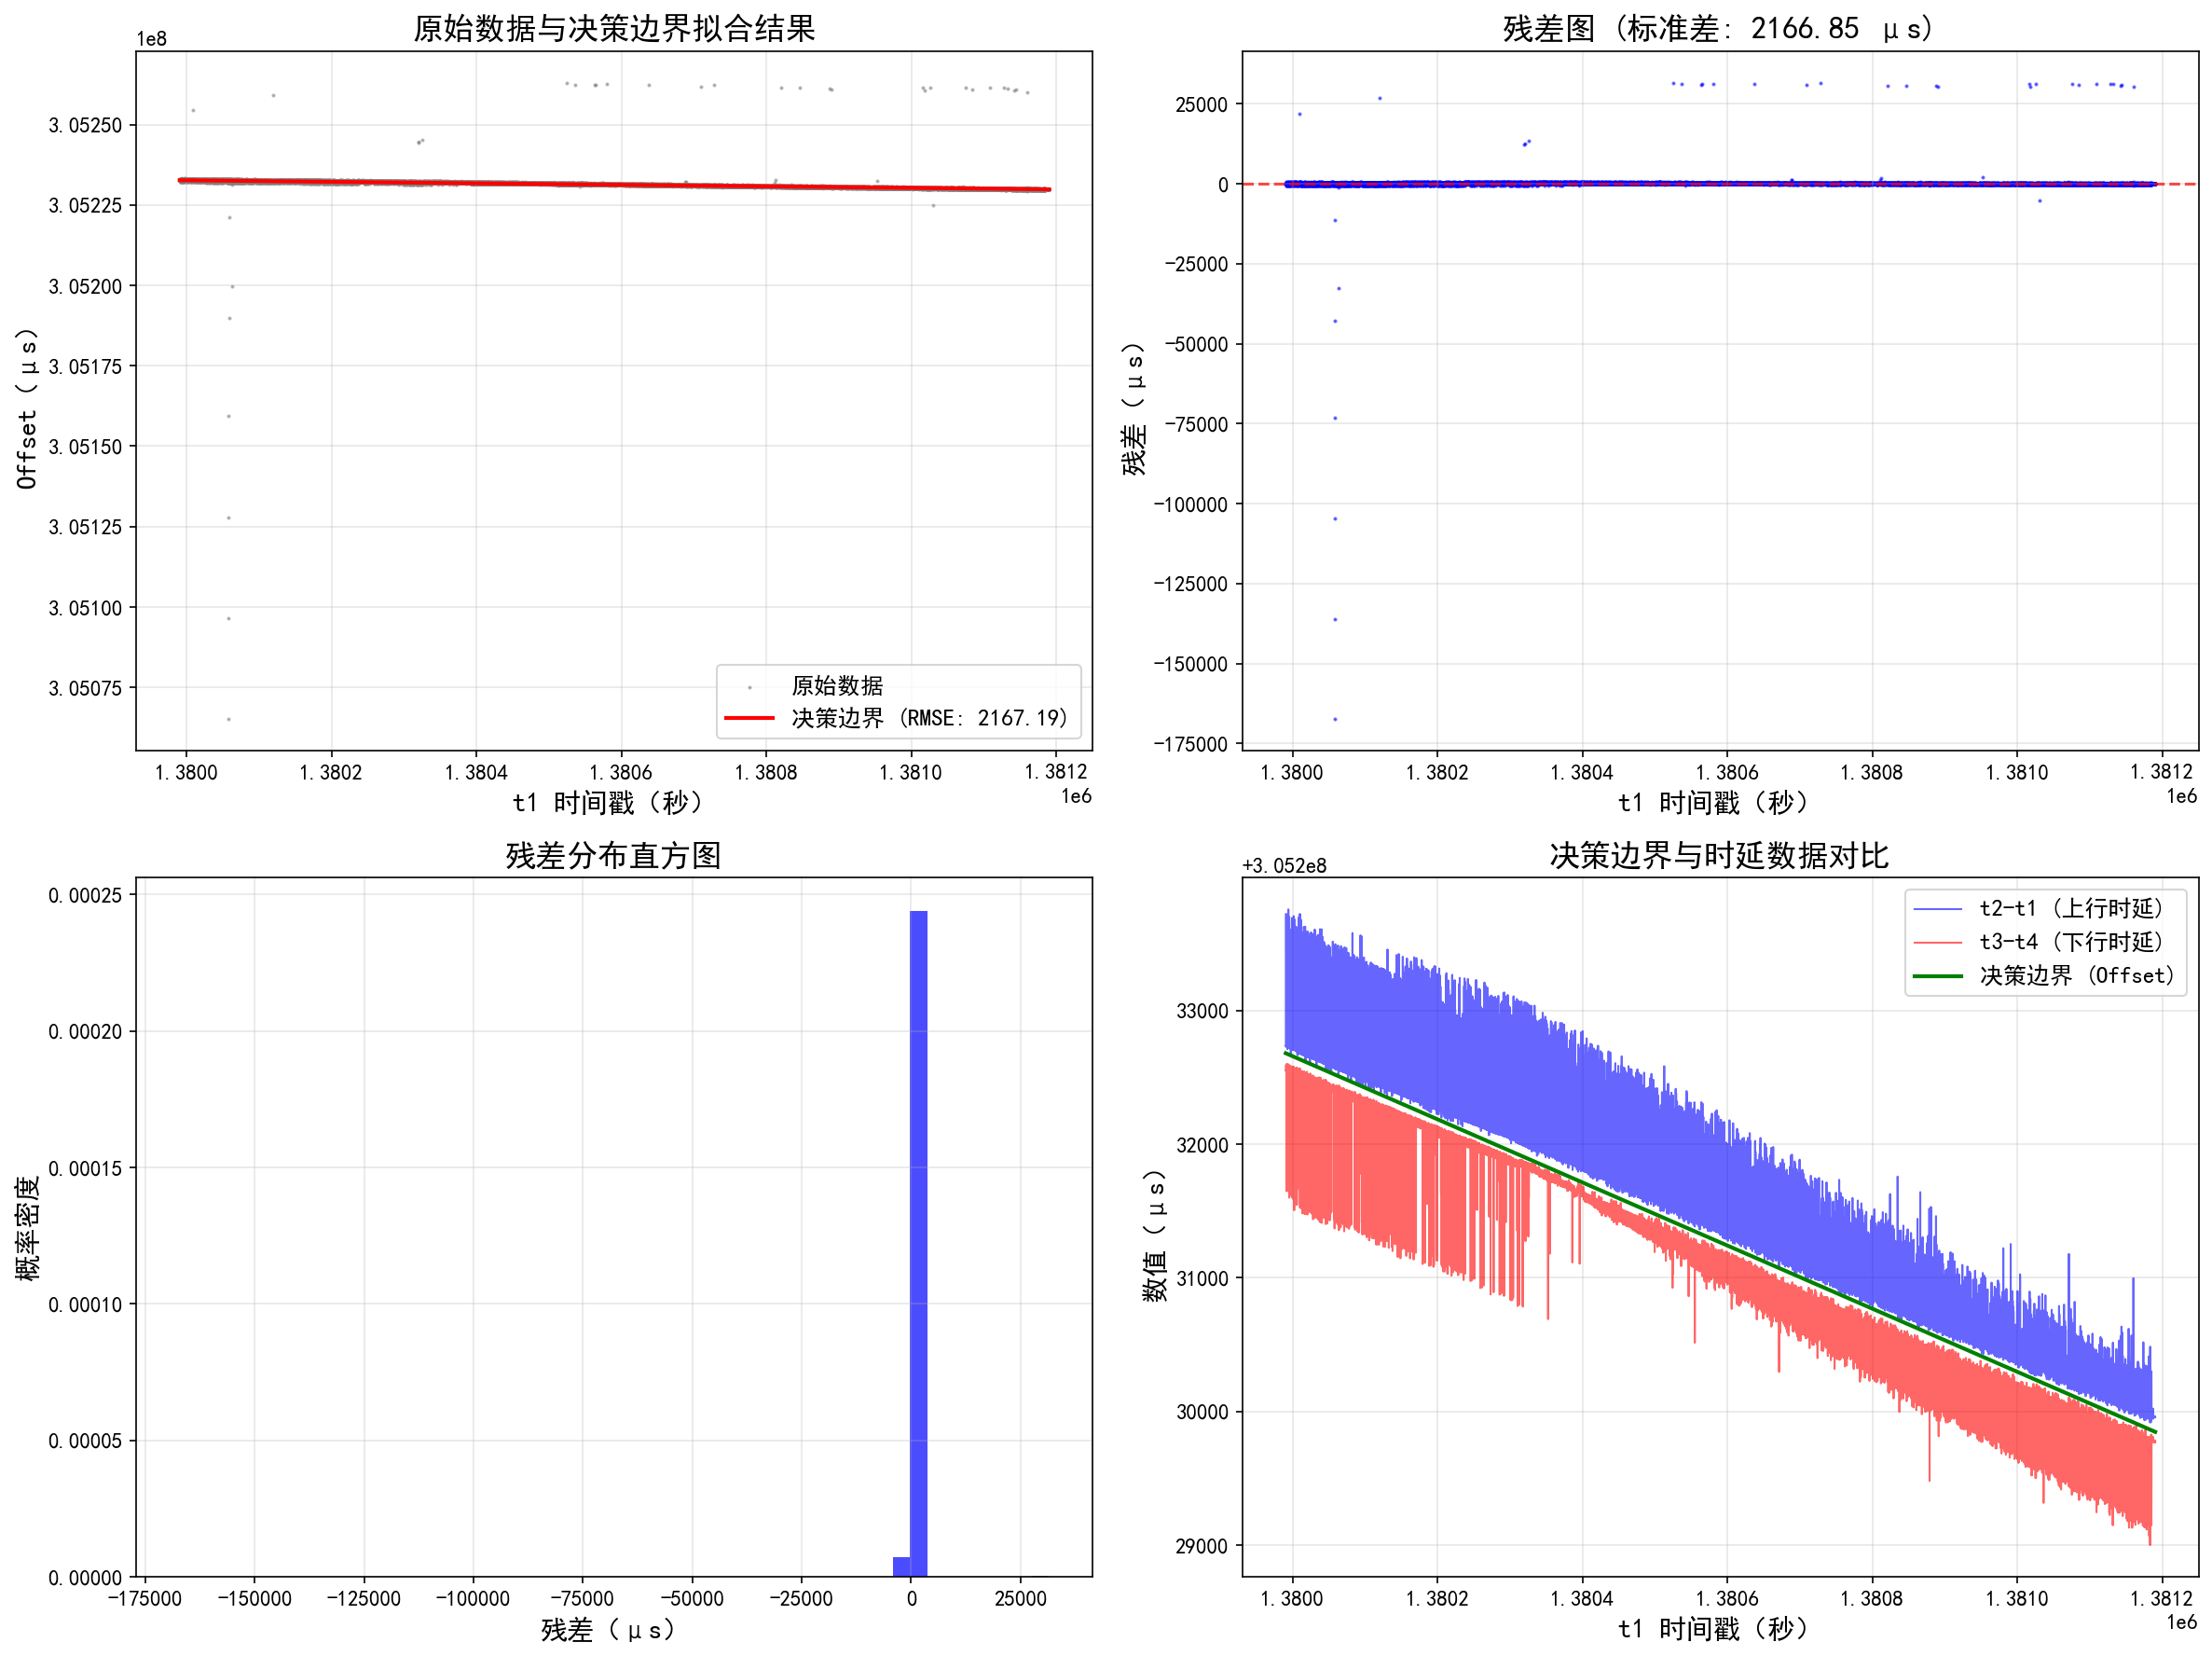

In [8]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def evaluate_decision_boundary(df, slope, intercept, scaler, save_svg=True):
    """
    评估决策边界的拟合效果，并生成可视化结果
    """
    # 获取原始数据
    df_filter = apply_percentile_filter(df,0.01,0.9)
    t1 = df['t1'].values
    t1_filter = df_filter['t1'].values
    y_offset = (df['t2t1'].values + df['t3t4'].values) / 2

    # 反标准化斜率和截距
    t1_mean, t1_std = scaler.mean_[0], scaler.scale_[0]
    delay_mean, delay_std = scaler.mean_[1], scaler.scale_[1]
    slope_original = slope * (delay_std / t1_std)
    intercept_original = intercept * delay_std + delay_mean - slope_original * t1_mean

    # 计算预测值
    y_pred = slope_original * t1 + intercept_original

    # 计算残差
    residuals = y_offset - y_pred
    rmse = np.sqrt(np.mean(residuals**2))
    # 计算评估指标
    mse = mean_squared_error(y_offset, y_pred)
    r2 = r2_score(y_offset, y_pred)
    print(f"决策边界评估结果:")
    print(f"  RMSE: {rmse:.2f} μs")
    print(f"  R²: {r2:.6f}")
    print(f"  残差标准差: {np.std(residuals):.2f} μs")

    # 创建图形 - 2x2布局
    plt.figure(figsize=(16, 12))

    # 子图1: 原始数据和决策边界
    plt.subplot(2, 2, 1)
    plt.scatter(t1, y_offset, color='gray', alpha=0.5, s=1, label='原始数据')
    plt.plot(t1, y_pred, color='red', linewidth=2, label=f'决策边界 (RMSE: {rmse:.2f})')
    plt.xlabel('t1 时间戳（秒）')
    plt.ylabel('Offset（μs）')
    plt.title('原始数据与决策边界拟合结果')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # 子图2: 残差图
    plt.subplot(2, 2, 2)
    plt.scatter(t1, residuals, color='blue', alpha=0.5, s=1)
    plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)
    plt.xlabel('t1 时间戳（秒）')
    plt.ylabel('残差（μs）')
    plt.title(f'残差图 (标准差: {np.std(residuals):.2f} μs)')
    plt.grid(True, alpha=0.3)

    # 子图3: 残差分布
    plt.subplot(2, 2, 3)
    plt.hist(residuals, bins=50, alpha=0.7, color='blue', density=True)
    plt.xlabel('残差（μs）')
    plt.ylabel('概率密度')
    plt.title('残差分布直方图')
    plt.grid(True, alpha=0.3)

    # 子图4: 决策边界与t2t1、t3t4的关系
    plt.subplot(2, 2, 4)
    plt.plot(t1_filter, df_filter['t2t1'].values, 'b-', alpha=0.6, linewidth=1, label='t2-t1 (上行时延)')
    plt.plot(t1_filter, df_filter['t3t4'].values, 'r-', alpha=0.6, linewidth=1, label='t3-t4 (下行时延)')
    plt.plot(t1, y_pred, 'g-', linewidth=2, label='决策边界 (Offset)')
    plt.xlabel('t1 时间戳（秒）')
    plt.ylabel('数值（μs）')
    plt.title('决策边界与时延数据对比')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    # 保存SVG格式
    if save_svg:
        svg_path = r"c:\Git_Code\Clock_Sync\results\decision_boundary_evaluation.svg"
        os.makedirs(os.path.dirname(svg_path), exist_ok=True)
        plt.savefig(svg_path, format='svg', bbox_inches='tight', dpi=300)
        print(f"📁 SVG图像已保存至: {svg_path}")

    plt.show()

# 调用评估函数
evaluate_decision_boundary(df_raw, slope, intercept, scaler)


🔧 分段SVM拟合 (分段数: 3)...
   分段 1: [1379990.45, 1380390.38] 5894 点, 准确率=1.00
   分段 2: [1380390.38, 1380790.30] 4990 点, 准确率=1.00
   分段 3: [1380790.30, 1381190.22] 4461 点, 准确率=1.00
✅ 分段SVM拟合完成
   总体RMSE: 155.19 μs
   总体R²: 0.968554
   有效分段数: 3
📁 SVG图像已保存至: c:\Git_Code\Clock_Sync\results\piecewise_svm_fitting_results.svg


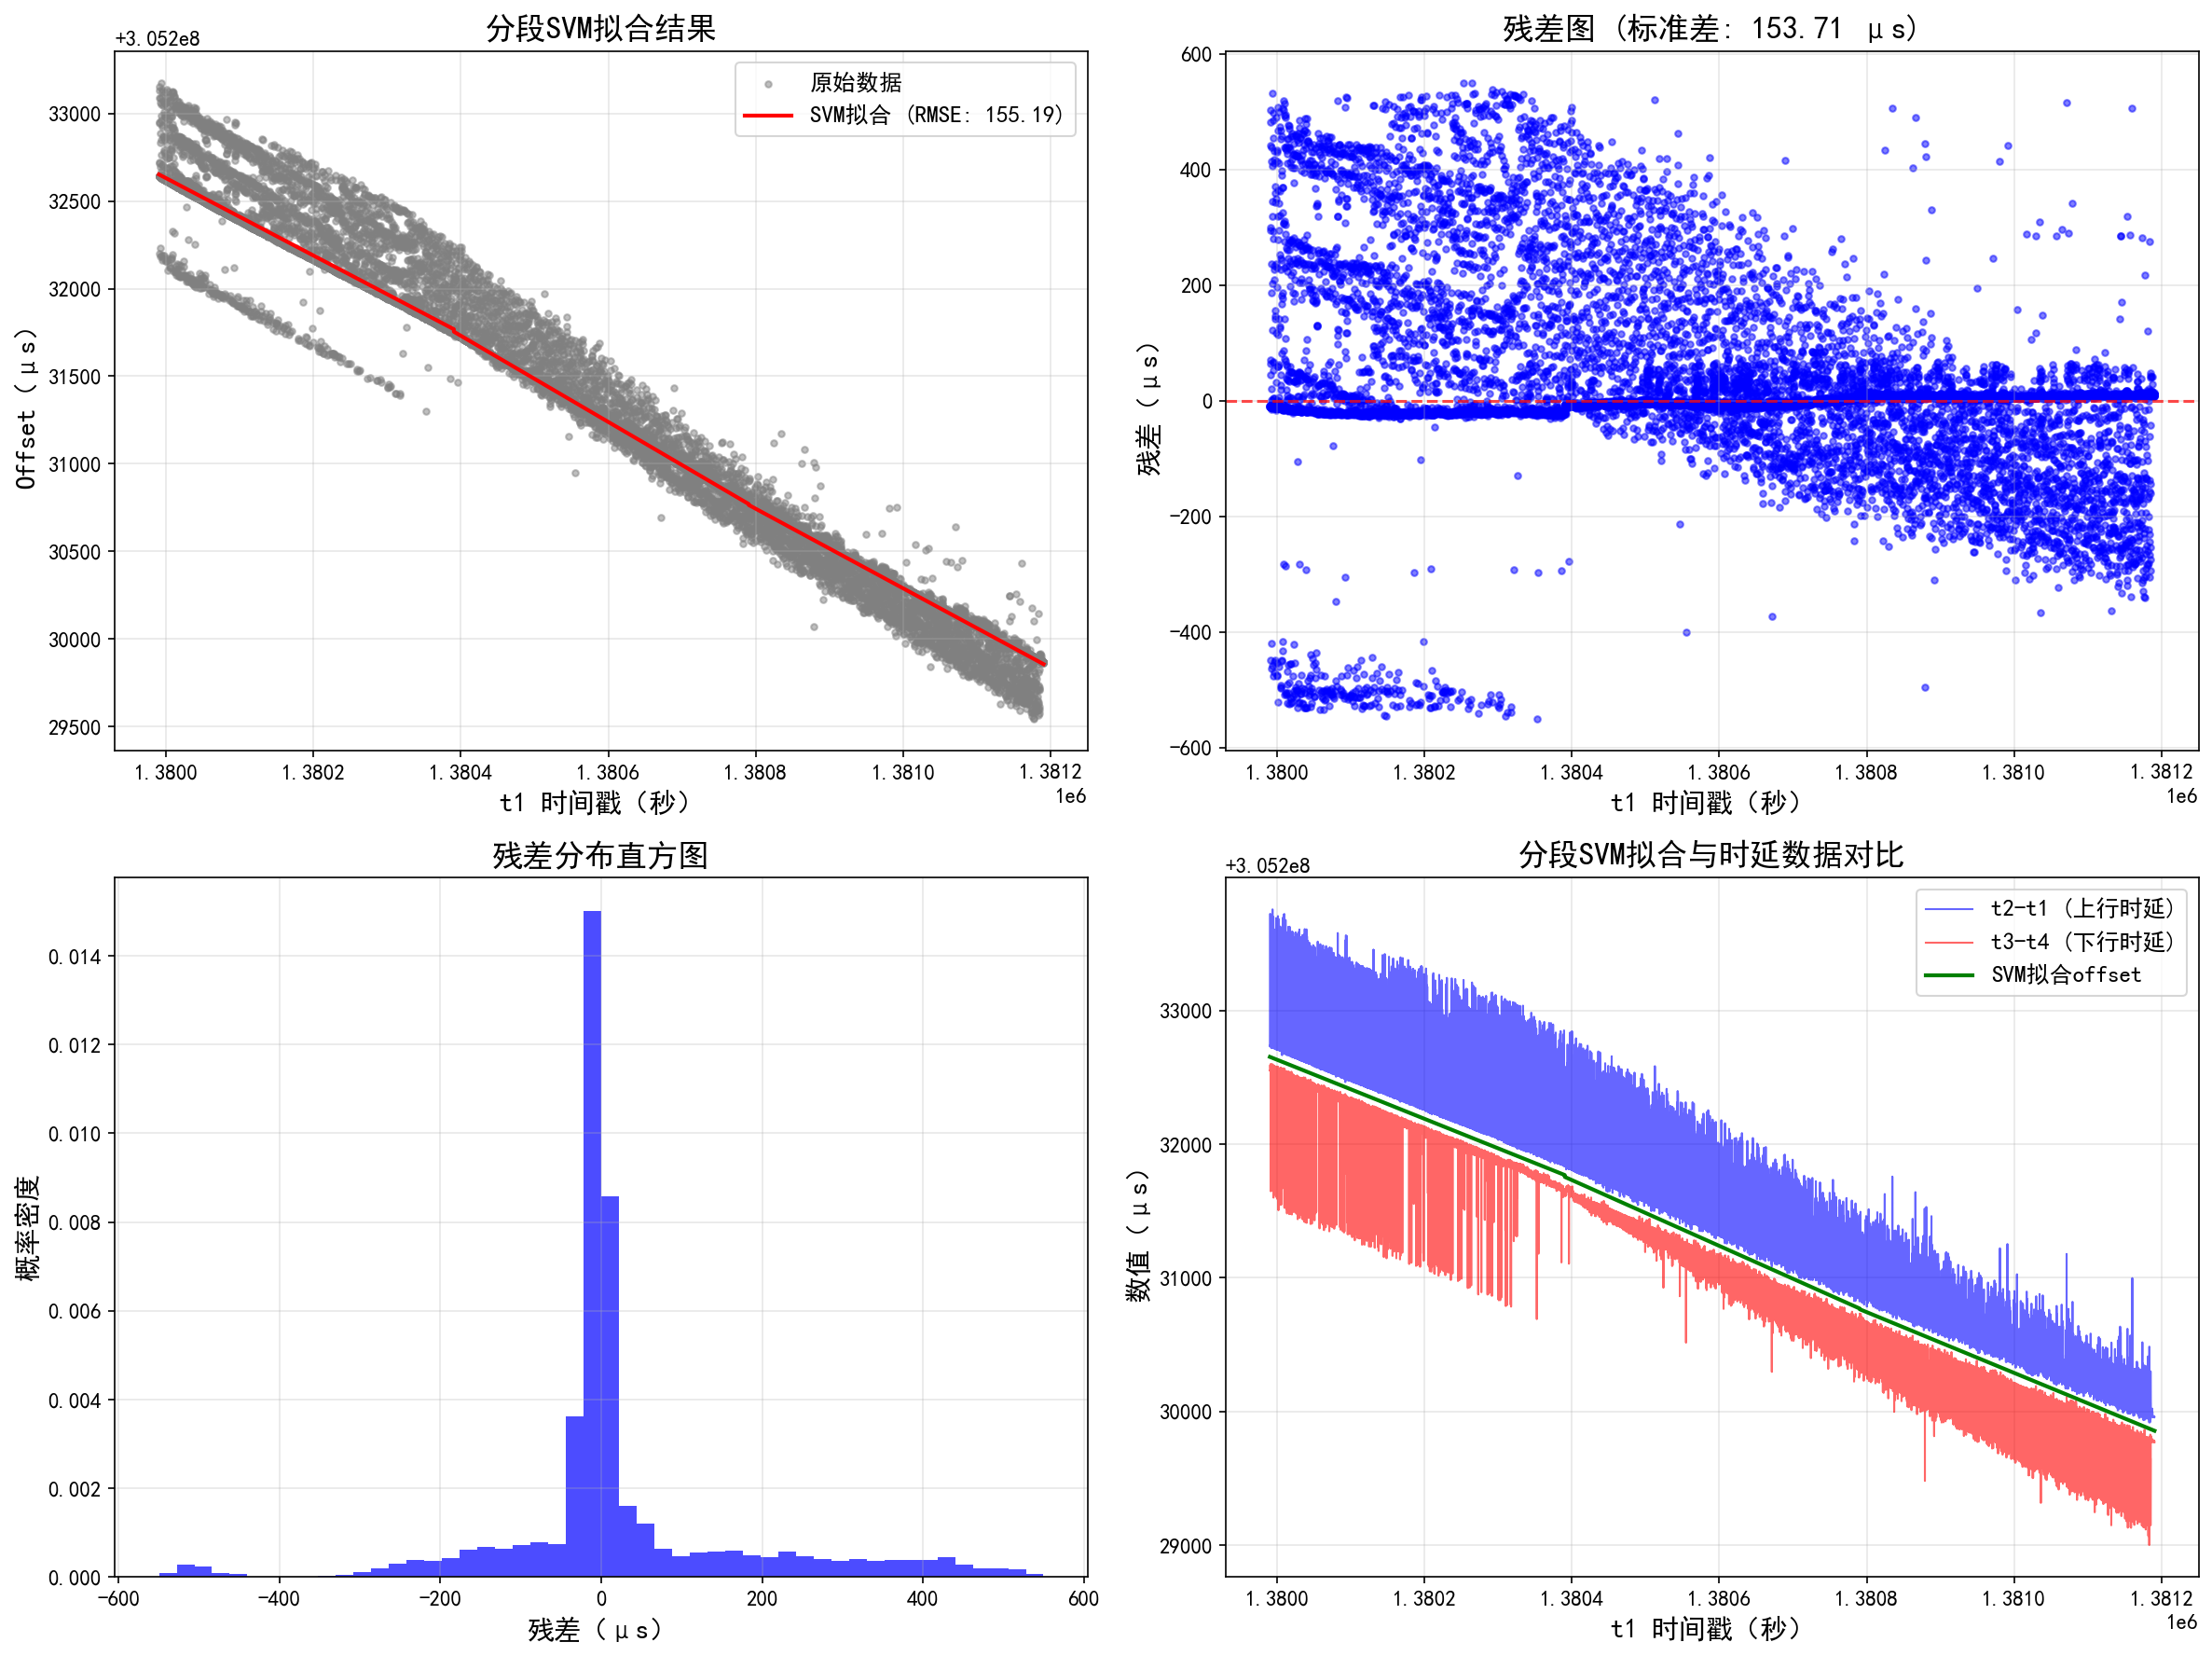

In [16]:
def piecewise_svm_fit(df, piece_num=10, C=1.0):
    """
    分段SVM拟合
    """
    print(f"\n🔧 分段SVM拟合 (分段数: {piece_num})...")
    
    # 准备数据
    df = df.copy().reset_index(drop=True)
    t1 = df['t1'].values
    y_up = df['t2t1'].values
    y_down = df['t3t4'].values
    y_offset = (y_up + y_down) / 2

    # 分段边界
    t1_min, t1_max = t1.min(), t1.max()
    piece_bounds = np.linspace(t1_min, t1_max, piece_num + 1)

    # 存储拟合结果
    piece_results = []
    y_pred = np.zeros_like(y_offset)
    
    for i in range(piece_num):
        # 分段数据
        if i == piece_num - 1:  # 最后一段包含右边界
            piece_mask = (t1 >= piece_bounds[i]) & (t1 <= piece_bounds[i + 1])
        else:
            piece_mask = (t1 >= piece_bounds[i]) & (t1 < piece_bounds[i + 1])
        
        t1_piece = t1[piece_mask]
        y_up_piece = y_up[piece_mask]
        y_down_piece = y_down[piece_mask]
        
        if len(t1_piece) < 2:  # 数据点太少，跳过
            print(f"   分段 {i+1}: 数据点太少 ({len(t1_piece)}), 跳过")
            continue
        
        # 准备训练数据
        X = np.concatenate([
            np.column_stack([t1_piece, y_up_piece]),
            np.column_stack([t1_piece, y_down_piece])
        ])
        y = np.concatenate([
            np.ones_like(y_up_piece),    # 上行为正类
            np.zeros_like(y_down_piece)  # 下行为负类
        ])

        # 标准化特征
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        # 拟合SVM
        clf = SVC(kernel='linear', C=C)
        clf.fit(X_scaled, y)

        # 提取斜率和截距
        w = clf.coef_[0]
        b = clf.intercept_[0]
        slope = -w[0] / w[1]
        intercept = -b / w[1]

        # 反标准化斜率和截距
        t1_mean, t1_std = scaler.mean_[0], scaler.scale_[0]
        delay_mean, delay_std = scaler.mean_[1], scaler.scale_[1]
        slope_original = slope * (delay_std / t1_std)
        intercept_original = intercept * delay_std + delay_mean - slope_original * t1_mean

        # 预测分段数据
        y_pred_piece = slope_original * t1_piece + intercept_original
        y_pred[piece_mask] = y_pred_piece

        # 保存结果
        piece_results.append({
            'piece': i,
            'x_range': (piece_bounds[i], piece_bounds[i + 1]),
            'slope': slope_original,
            'intercept': intercept_original,
            'n_points': len(t1_piece),
            'accuracy': clf.score(X_scaled, y)
        })
        print(f"   分段 {i+1}: [{piece_bounds[i]:.2f}, {piece_bounds[i+1]:.2f}] {len(t1_piece)} 点, 准确率={clf.score(X_scaled, y):.2f}")

    # 计算整体拟合质量
    residuals = y_offset - y_pred
    overall_rmse = np.sqrt(np.mean(residuals**2))
    overall_r2 = 1 - np.sum(residuals**2) / np.sum((y_offset - np.mean(y_offset))**2)

    print(f"✅ 分段SVM拟合完成")
    print(f"   总体RMSE: {overall_rmse:.2f} μs")
    print(f"   总体R²: {overall_r2:.6f}")
    print(f"   有效分段数: {len(piece_results)}")

    return {
        'method': 'Piecewise SVM',
        'y_pred': y_pred,
        'rmse': overall_rmse,
        'r2': overall_r2,
        'piece_results': piece_results,
        'piece_num': piece_num
    }

def plot_piecewise_svm_results(df, piecewise_svm_result, save_svg=True):
    """
    绘制分段SVM拟合结果
    """
    # 准备数据
    t1 = df['t1'].values
    y_offset = (df['t2t1'].values + df['t3t4'].values) / 2
    y_pred = piecewise_svm_result['y_pred']
    residuals = y_offset - y_pred

    # 创建图形 - 2x2布局
    plt.figure(figsize=(16, 12))

    # 子图1: 原始数据和拟合结果
    plt.subplot(2, 2, 1)
    plt.scatter(t1, y_offset, color='gray', alpha=0.5, s=10, label='原始数据')
    plt.plot(t1, y_pred, color='red', linewidth=2, label=f'SVM拟合 (RMSE: {piecewise_svm_result["rmse"]:.2f})')
    plt.xlabel('t1 时间戳（秒）')
    plt.ylabel('Offset（μs）')
    plt.title('分段SVM拟合结果')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # 子图2: 残差图
    plt.subplot(2, 2, 2)
    plt.scatter(t1, residuals, color='blue', alpha=0.5, s=10)
    plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)
    plt.xlabel('t1 时间戳（秒）')
    plt.ylabel('残差（μs）')
    plt.title(f'残差图 (标准差: {np.std(residuals):.2f} μs)')
    plt.grid(True, alpha=0.3)

    # 子图3: 残差分布
    plt.subplot(2, 2, 3)
    plt.hist(residuals, bins=50, alpha=0.7, color='blue', density=True)
    plt.xlabel('残差（μs）')
    plt.ylabel('概率密度')
    plt.title('残差分布直方图')
    plt.grid(True, alpha=0.3)

    # 子图4: 分段SVM拟合结果与t2t1、t3t4的关系
    plt.subplot(2, 2, 4)
    plt.plot(t1, df['t2t1'].values, 'b-', alpha=0.6, linewidth=1, label='t2-t1 (上行时延)')
    plt.plot(t1, df['t3t4'].values, 'r-', alpha=0.6, linewidth=1, label='t3-t4 (下行时延)')
    plt.plot(t1, y_pred, 'g-', linewidth=2, label='SVM拟合offset')
    plt.xlabel('t1 时间戳（秒）')
    plt.ylabel('数值（μs）')
    plt.title('分段SVM拟合与时延数据对比')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    # 保存SVG格式
    if save_svg:
        svg_path = r"c:\Git_Code\Clock_Sync\results\piecewise_svm_fitting_results.svg"
        os.makedirs(os.path.dirname(svg_path), exist_ok=True)
        plt.savefig(svg_path, format='svg', bbox_inches='tight', dpi=300)
        print(f"📁 SVG图像已保存至: {svg_path}")

    plt.show()

# 执行分段SVM拟合
piecewise_svm_result = piecewise_svm_fit(df, piece_num=3, C=0.1)

# 绘制结果
plot_piecewise_svm_results(df, piecewise_svm_result)